# 1D Viscous Burgers — LC-PINN Benchmark

**Equation:** $u_t + u \, u_x - \nu \, u_{xx} = 0$, with $\nu = 0.01/\pi$ (Raissi et al. setup).

**Domain:** $x \in [-1, 1]$, $t \in [0, 1]$. IC: $u(0, x) = -\sin(\pi x)$. BC: $u(t, \pm 1) = 0$.

**Loss terms (4):** PDE residual, BC (Dirichlet), IC, sparse interior data → `dim_lambda = 4`.

**Reference:** Pseudo-spectral (Fourier + RK4) on fine grid.

**Purpose:** Core PINN benchmark from the literature. Convection-diffusion with sharp internal layer at low viscosity. Standard test case for loss-balancing methods (ReLoBRaLo, etc.).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from pinns.model import LossConditionalPINN
from pinns.baseline import FixedWeightPINN, train_fixed_pinn
from pinns.training import train_lc_pinn
from pinns.lambda_sampler import LambdaSampler
from pinns.inference import sweep_lambda
from pinns.device import select_device, device_info

from pinns.equations import burgers as eq

device = select_device()
print(f"Device: {device_info(device)}")
torch.manual_seed(42)
np.random.seed(42)

HIDDEN_DIMS = [64, 64, 64, 64]
N_STEPS = 200_000   # Burgers needs more steps than logistic but less than BL
LR = 1e-3
LOG_EVERY = 5_000

Device: mps (Apple GPU)


/Users/anna/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Reference solution & training data

Computing spectral reference solution...
Snapshot times: [0.25, 0.5, 0.75, 1.0]


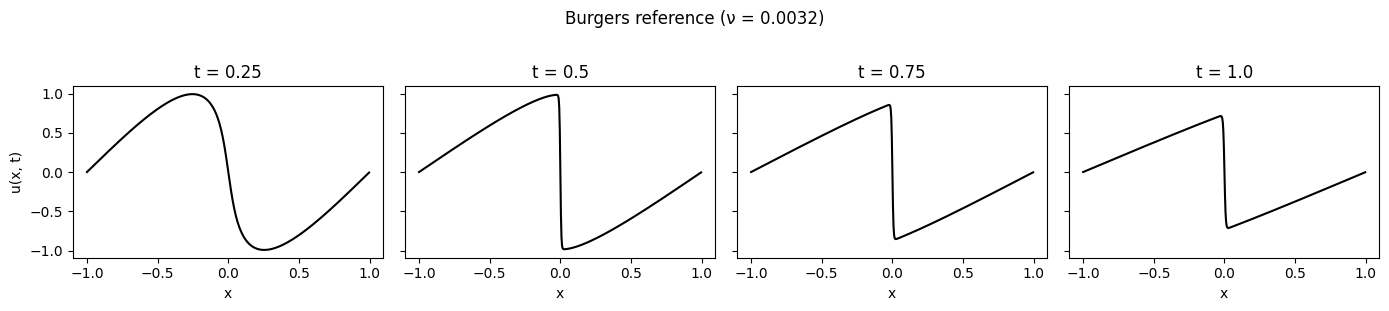

In [2]:
print("Computing spectral reference solution...")
ref_snapshots = eq.compute_reference_solution()
batch = eq.generate_training_data(ref_snapshots, device=device)

snap_times = sorted(ref_snapshots.keys())
print(f"Snapshot times: {snap_times}")

fig, axes = plt.subplots(1, len(snap_times), figsize=(3.5 * len(snap_times), 3), sharey=True)
for ax, t_val in zip(axes, snap_times):
    x_ref, u_ref = ref_snapshots[t_val]
    ax.plot(x_ref, u_ref, 'k-', lw=1.5)
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
axes[0].set_ylabel('u(x, t)')
fig.suptitle(f'Burgers reference (ν = {eq.NU:.4f})', y=1.02)
plt.tight_layout()
plt.show()

## 2. Train LC-PINN

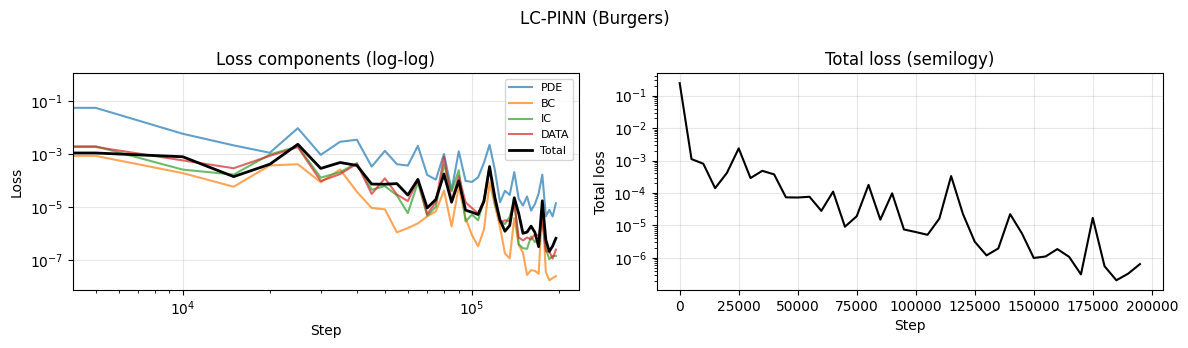

Training: 100%|██████████| 200000/200000 [1:21:22<00:00, 40.96step/s, L=6.49e-07, hw=3.00]



Training complete in 4883s (81.4 min)
Best log(lambda):     [-0.841  2.59   2.763  1.958]
Best softmax(lambda): [0.0118 0.3632 0.4319 0.1931]
Best validation loss: 2.052855e-07

LC-PINN rel-L2 per snapshot: {0.25: 0.00049035582922388, 0.5: 0.0008421330605777573, 0.75: 0.0009707437897184698, 1.0: 0.001361890866437591}
Mean: 0.0009


In [3]:
def make_live_plot_callback(title="Training"):
    def on_log(history):
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
        fig.suptitle(title)
        steps = history["step"]
        ax1.set_title("Loss components (log-log)")
        for key in history:
            if key in ("step", "total", "hw", "elapsed_sec"): continue
            ax1.plot(steps, history[key], label=key.upper(), alpha=0.7)
        ax1.plot(steps, history["total"], 'k-', lw=2, label="Total")
        ax1.set_xscale("log"); ax1.set_yscale("log")
        ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
        ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
        ax2.set_title("Total loss (semilogy)")
        ax2.semilogy(steps, history["total"], 'k-', lw=1.5)
        ax2.set_xlabel("Step"); ax2.set_ylabel("Total loss"); ax2.grid(True, alpha=0.3)
        fig.tight_layout(); plt.show(); plt.close(fig)
    return on_log

model_lc = LossConditionalPINN(eq.DIM_PHYS, eq.DIM_LAMBDA, HIDDEN_DIMS).to(device)
sampler = LambdaSampler(dim=eq.DIM_LAMBDA, device=device)

history_lc = train_lc_pinn(
    model_lc, sampler, batch, device,
    loss_fn=eq.compute_losses,
    n_epochs=N_STEPS, lr=LR, log_every=LOG_EVERY,
    on_log=make_live_plot_callback("LC-PINN (Burgers)"),
)

best_ll, best_p, _ = sweep_lambda(
    model_lc, batch, sampler, device,
    loss_fn=eq.compute_losses,
    n_candidates=500,
    exclude_terms={"pde"},
)

torch.save({
    "model_state_dict": model_lc.state_dict(),
    "best_log_lambda": best_ll,
}, "../checkpoints/burgers_lc_pinn.pt")

lc_errors = eq.evaluate(model_lc, best_ll, ref_snapshots, device)
print(f"\nLC-PINN rel-L2 per snapshot: {lc_errors}")
print(f"Mean: {np.mean(list(lc_errors.values())):.4f}")

## 3. Equal-weight baseline

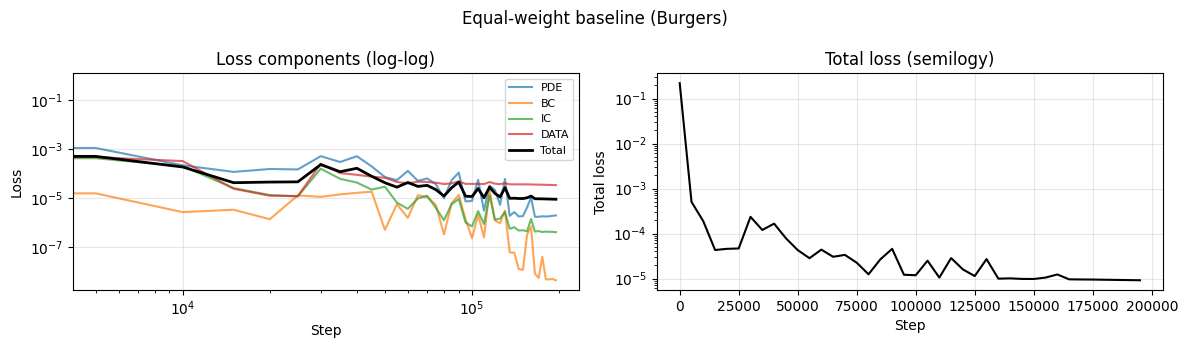

Equal-weight baseline: 100%|██████████| 200000/200000 [19:02<00:00, 175.04step/s, L=9.14e-06]

Equal-weight baseline done in 1143s (19.0 min)

Baseline rel-L2: {0.25: 0.0012071952992211647, 0.5: 0.1243430914389008, 0.75: 0.265665375551821, 1.0: 0.1977228351577044}
Mean: 0.1472


In [4]:
model_baseline = FixedWeightPINN(eq.DIM_PHYS, HIDDEN_DIMS).to(device)
baseline_history = train_fixed_pinn(
    model_baseline,
    weights=[0.25, 0.25, 0.25, 0.25],
    batch=batch, device=device,
    loss_fn=eq.compute_losses_fixed,
    n_epochs=N_STEPS, lr=LR, log_every=LOG_EVERY,
    desc="Equal-weight baseline",
    on_log=make_live_plot_callback("Equal-weight baseline (Burgers)"),
)

torch.save({"model_state_dict": model_baseline.state_dict()},
           "../checkpoints/burgers_baseline.pt")

baseline_errors = eq.evaluate(model_baseline, None, ref_snapshots, device)
print(f"\nBaseline rel-L2: {baseline_errors}")
print(f"Mean: {np.mean(list(baseline_errors.values())):.4f}")

## 4. Comparison

Method                      t=0.25  t=0.50  t=0.75  t=1.00   Mean
-----------------------------------------------------------------
LC-PINN (best λ)            0.0005  0.0008  0.0010  0.0014  0.0009
Equal-weight baseline       0.0012  0.1243  0.2657  0.1977  0.1472


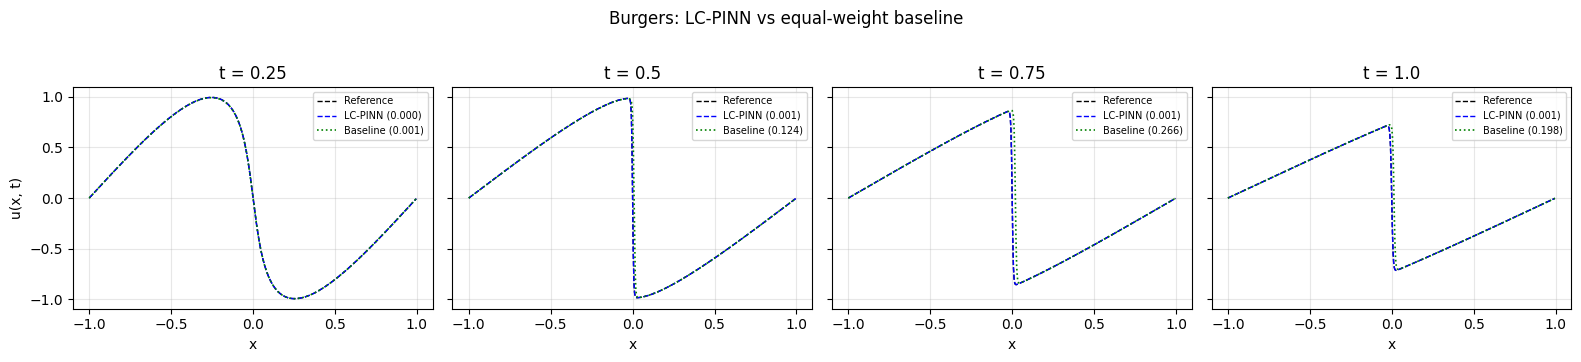

Saved: results/fig_burgers_comparison.png


In [14]:
# --- Comparison table ---
results = {"LC-PINN (best λ)": lc_errors, "Equal-weight baseline": baseline_errors}
header = f"{'Method':<26}" + "".join(f"  t={t:.2f}" for t in snap_times) + "   Mean"
print(header)
print("-" * len(header))
for name, errs in results.items():
    vals = [errs[t] for t in snap_times]
    row = f"{name:<26}" + "".join(f"  {v:.4f}" for v in vals) + f"  {np.mean(vals):.4f}"
    print(row)

# --- Side-by-side prediction plots ---
fig, axes = plt.subplots(1, len(snap_times), figsize=(4 * len(snap_times), 3.5), sharey=True)
for ax, t_val in zip(axes, snap_times):
    x_ref, u_ref = ref_snapshots[t_val]
    u_lc = eq.predict_solution(model_lc, best_ll, x_ref, t_val, device)
    u_base = eq.predict_solution(model_baseline, None, x_ref, t_val, device)
    ax.plot(x_ref, u_ref, 'k--', lw=1, label='Reference')
    ax.plot(x_ref, u_lc, 'b--', lw=1, label=f'LC-PINN ({lc_errors[t_val]:.3f})')
    ax.plot(x_ref, u_base, 'g:', lw=1.2, label=f'Baseline ({baseline_errors[t_val]:.3f})')
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
axes[0].set_ylabel('u(x, t)')
fig.suptitle('Burgers: LC-PINN vs equal-weight baseline', y=1.02)
plt.tight_layout()
plt.savefig('../results/fig_burgers_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/fig_burgers_comparison.png")